In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

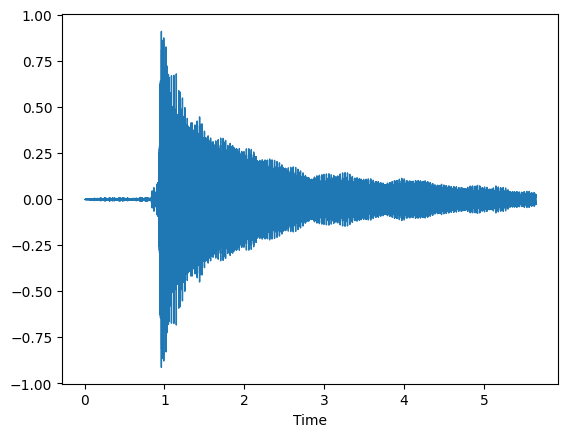

In [3]:
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav', sr=22050)

librosa.display.waveshow(y, sr=sr, axis='time', )

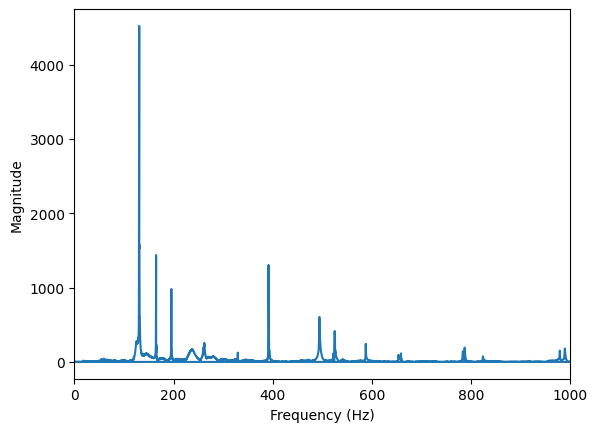

In [4]:
# FT of the whole signal
spectrum = np.abs(np.fft.fft(y))
freqs = np.fft.fftfreq(len(y), d=1/sr)

plt.plot(freqs, spectrum)
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

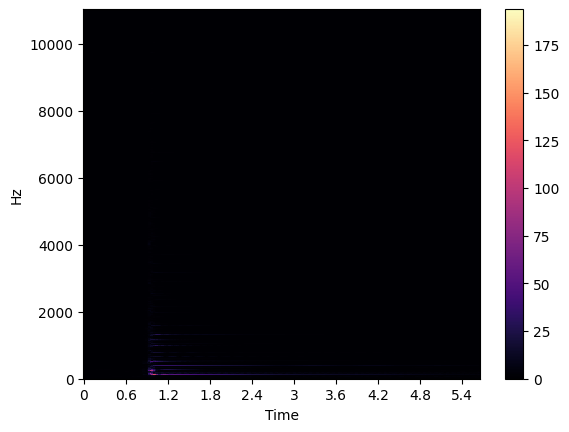

In [5]:
# STFT of the signal
stft = np.abs(librosa.stft(y))
librosa.display.specshow(stft, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar()

Real audio has a huge range of amplitudes. A linear color scale spreads its colors evenly across raw values, so it puts almost all its range on the one loudest bin, and everything much quieter just rounds down to black. Taking the log converts those huge multiplicative differences into small steps, so quiet and loud parts both get spread across visible colors instead of the quiet ones disappearing.

$$
dB = 20 \log_{10}\left(\frac{\text{amplitude}}{\text{max amplitude}}\right)
$$

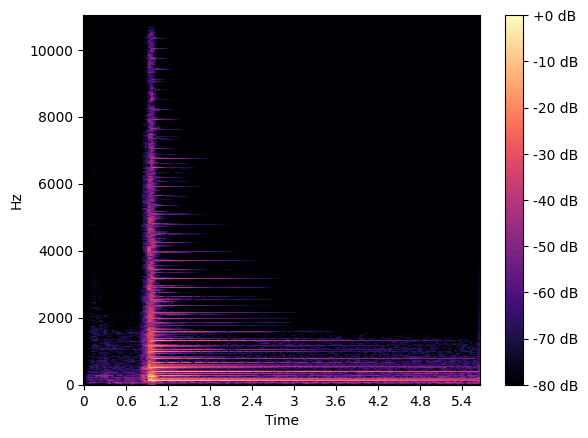

In [6]:
# Log-scaled STFT / Spectrogram
log_stft = librosa.amplitude_to_db(stft, ref=np.max)
librosa.display.specshow(log_stft, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')

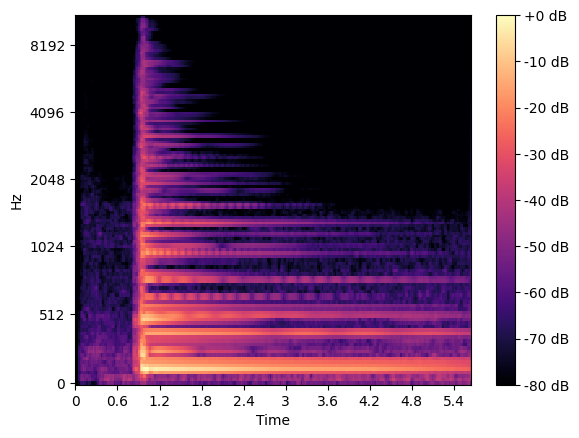

In [7]:
# Mel spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
librosa.display.specshow(librosa.power_to_db(mel_spectrogram, ref=np.max), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

[Text(0.5, 1.0, 'Mel Spectrogram')]

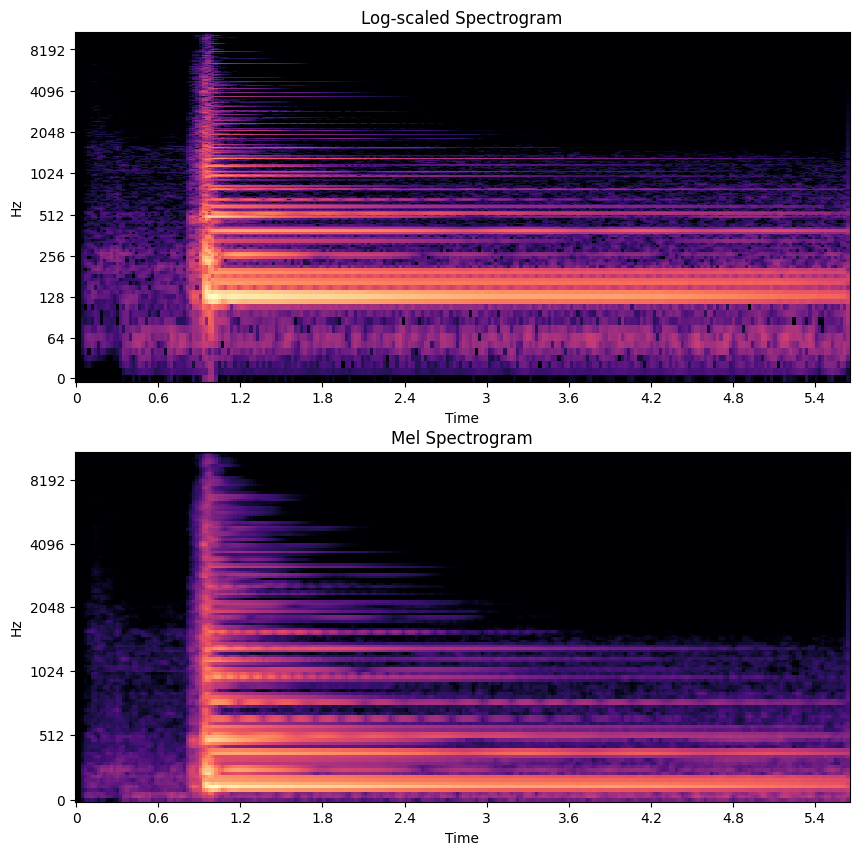

In [8]:
# Plot mel spectrogram and log-scaled spectrogram
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
# Log-scaled spectrogram
librosa.display.specshow(log_stft, sr=sr, x_axis='time', y_axis='log', ax=ax[0])
ax[0].set(title='Log-scaled Spectrogram')
# Mel spectrogram
librosa.display.specshow(librosa.power_to_db(mel_spectrogram, ref=np.max), sr=sr, x_axis='time', y_axis='mel', ax=ax[1])
ax[1].set(title='Mel Spectrogram')